In [1]:
"""
Security Intelligence - Analysis & Experimentation

Milestone 3:
Occupancy & Security Intelligence

This notebook explores physical access-control events
and develops the security intelligence pipeline.

Main objectives:
- Analyze access-control events
- Understand normal and anomalous behavior
- Investigate security scenarios
- Develop anomaly/risk detection logic
- Evaluate security detection performance
- Prepare logic for the Security Agent
"""

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Display configuration
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 120)


print("Security Intelligence Analysis")
print("Python environment is ready.")

Security Intelligence Analysis
Python environment is ready.


In [2]:
# -------------------------------------------------------------------
# Project paths
# -------------------------------------------------------------------

NOTEBOOK_DIR = Path.cwd()

SECURITY_SYSTEM_DIR = NOTEBOOK_DIR.parent

RAW_DATA_DIR = SECURITY_SYSTEM_DIR / "data" / "raw"
PROCESSED_DATA_DIR = SECURITY_SYSTEM_DIR / "data" / "processed"
OUTPUT_DIR = SECURITY_SYSTEM_DIR / "outputs"


print("Security System:")
print(SECURITY_SYSTEM_DIR)

print("\nRaw Data:")
print(RAW_DATA_DIR)

print("\nProcessed Data:")
print(PROCESSED_DATA_DIR)

print("\nOutput Directory:")
print(OUTPUT_DIR)

Security System:
c:\Users\sarod\Desktop\Springboard\M3_Occupancy_and_Security_Intelligence\security_system

Raw Data:
c:\Users\sarod\Desktop\Springboard\M3_Occupancy_and_Security_Intelligence\security_system\data\raw

Processed Data:
c:\Users\sarod\Desktop\Springboard\M3_Occupancy_and_Security_Intelligence\security_system\data\processed

Output Directory:
c:\Users\sarod\Desktop\Springboard\M3_Occupancy_and_Security_Intelligence\security_system\outputs


In [3]:
# -------------------------------------------------------------------
# Verify required raw data files
# -------------------------------------------------------------------

required_files = [
    "access_logs_final.csv",
    "agent_profiles.json",
    "anomaly_ground_truth.json",
    "scenario_expectations.csv",
]

print("Raw dataset files:\n")

for filename in required_files:

    file_path = RAW_DATA_DIR / filename

    status = "FOUND" if file_path.exists() else "MISSING"

    print(f"{filename:<30} {status}")

Raw dataset files:

access_logs_final.csv          FOUND
agent_profiles.json            FOUND
anomaly_ground_truth.json      FOUND
scenario_expectations.csv      FOUND


In [4]:
# -------------------------------------------------------------------
# Load access-control logs
# -------------------------------------------------------------------

access_log_path = RAW_DATA_DIR / "access_logs_final.csv"

access_logs = pd.read_csv(
    access_log_path,
    low_memory=False
)

print("Access logs loaded successfully.")

print("\nShape:")
print(access_logs.shape)

print("\nNumber of records:", len(access_logs))
print("Number of columns:", len(access_logs.columns))

Access logs loaded successfully.

Shape:
(91388, 20)

Number of records: 91388
Number of columns: 20


In [5]:
# -------------------------------------------------------------------
# Inspect column names
# -------------------------------------------------------------------

print("Access log columns:\n")

for index, column in enumerate(access_logs.columns, start=1):
    print(f"{index:2}. {column}")

Access log columns:

 1. log_id
 2. timestamp
 3. session_id
 4. user_id
 5. agent_type
 6. robot_type
 7. human_role
 8. action
 9. resource
10. resource_type
11. human_present
12. emergency_flag
13. location
14. previous_action
15. is_anomaly
16. anomaly_type
17. scenario_id
18. production_state
19. shift_id
20. correlation_id


In [6]:
# -------------------------------------------------------------------
# Inspect sample records
# -------------------------------------------------------------------

display(
    access_logs.head(10)
)

,log_id,timestamp,session_id,user_id,agent_type,robot_type,human_role,action,resource,resource_type,human_present,emergency_flag,location,previous_action,is_anomaly,anomaly_type,scenario_id,production_state,shift_id,correlation_id
0,log_0000001,2026-01-05T00:14:19.091821,sess_plc_safety_02_00,plc_safety_02,robot,safety_plc,NaN,read_sensor,sensor_emergency_stop_02,sensor,False,False,zone_safety_systems,NaN,False,NaN,NaN,idle,off_hours,NaN
1,log_0000002,2026-01-05T00:14:23.839484,sess_plc_safety_01_00,plc_safety_01,robot,safety_plc,NaN,read_sensor,sensor_emergency_stop_01,sensor,False,False,zone_safety_systems,NaN,False,NaN,NaN,idle,off_hours,NaN
2,log_0000003,2026-01-05T00:28:48.677166,sess_plc_safety_02_00,plc_safety_02,robot,safety_plc,NaN,write_log,database_alerts,database,False,False,zone_server_room,read_sensor,False,NaN,NaN,idle,off_hours,NaN
3,log_0000004,2026-01-05T00:28:57.151507,sess_plc_safety_01_00,plc_safety_01,robot,safety_plc,NaN,write_log,database_alerts,database,False,False,zone_server_room,read_sensor,False,NaN,NaN,idle,off_hours,NaN
4,log_0000005,2026-01-05T00:43:05.385145,sess_plc_safety_02_00,plc_safety_02,robot,safety_plc,NaN,read_sensor,sensor_emergency_stop_02,sensor,False,False,zone_safety_systems,write_log,False,NaN,NaN,idle,off_hours,NaN
5,log_0000006,2026-01-05T00:43:29.946491,sess_plc_safety_01_00,plc_safety_01,robot,safety_plc,NaN,read_sensor,sensor_emergency_stop_01,sensor,False,False,zone_safety_systems,write_log,False,NaN,NaN,idle,off_hours,NaN
6,log_0000007,2026-01-05T00:57:41.135703,sess_plc_safety_02_00,plc_safety_02,robot,safety_plc,NaN,write_log,database_alerts,database,False,False,zone_server_room,read_sensor,False,NaN,NaN,idle,off_hours,NaN
7,log_0000008,2026-01-05T00:57:50.739570,sess_plc_safety_01_00,plc_safety_01,robot,safety_plc,NaN,write_log,database_alerts,database,False,False,zone_server_room,read_sensor,False,NaN,NaN,idle,off_hours,NaN
8,log_0000009,2026-01-05T01:12:02.478589,sess_plc_safety_02_00,plc_safety_02,robot,safety_plc,NaN,read_sensor,sensor_emergency_stop_02,sensor,False,False,zone_safety_systems,write_log,False,NaN,NaN,idle,off_hours,NaN
9,log_0000010,2026-01-05T01:12:06.801725,sess_plc_safety_01_00,plc_safety_01,robot,safety_plc,NaN,read_sensor,sensor_emergency_stop_01,sensor,False,False,zone_safety_systems,write_log,False,NaN,NaN,idle,off_hours,NaN


In [7]:
# -------------------------------------------------------------------
# Data types
# -------------------------------------------------------------------

print("Column data types:\n")

display(
    access_logs.dtypes.to_frame(
        name="dtype"
    )
)

Column data types:



,dtype
log_id,object
timestamp,object
session_id,object
user_id,object
agent_type,object
robot_type,object
human_role,object
action,object
resource,object
resource_type,object


In [8]:
# -------------------------------------------------------------------
# Dataset information
# -------------------------------------------------------------------

access_logs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91388 entries, 0 to 91387
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   log_id            91388 non-null  object
 1   timestamp         91388 non-null  object
 2   session_id        91388 non-null  object
 3   user_id           91388 non-null  object
 4   agent_type        91388 non-null  object
 5   robot_type        66503 non-null  object
 6   human_role        24885 non-null  object
 7   action            91388 non-null  object
 8   resource          91388 non-null  object
 9   resource_type     91388 non-null  object
 10  human_present     91388 non-null  bool  
 11  emergency_flag    91388 non-null  bool  
 12  location          91388 non-null  object
 13  previous_action   91321 non-null  object
 14  is_anomaly        91388 non-null  bool  
 15  anomaly_type      2672 non-null   object
 16  scenario_id       150 non-null    object
 17  production_s

In [9]:
# -------------------------------------------------------------------
# Missing-value analysis
# -------------------------------------------------------------------

missing_summary = pd.DataFrame({
    "missing_count": access_logs.isna().sum(),
    "missing_percent": (
        access_logs.isna().mean() * 100
    ).round(2)
})

missing_summary = missing_summary.sort_values(
    "missing_count",
    ascending=False
)

display(missing_summary)

,missing_count,missing_percent
correlation_id,91348,99.96
scenario_id,91238,99.84
anomaly_type,88716,97.08
human_role,66503,72.77
robot_type,24885,27.23
previous_action,67,0.07
timestamp,0,0.00
log_id,0,0.00
user_id,0,0.00
session_id,0,0.00


In [10]:
# -------------------------------------------------------------------
# Duplicate analysis
# -------------------------------------------------------------------

duplicate_count = access_logs.duplicated().sum()

print("Duplicate rows:", duplicate_count)

print(
    "Duplicate percentage:",
    round(
        duplicate_count / len(access_logs) * 100,
        2
    ),
    "%"
)

Duplicate rows: 0
Duplicate percentage: 0.0 %


In [11]:
# -------------------------------------------------------------------
# Timestamp processing
# -------------------------------------------------------------------

access_logs["timestamp"] = pd.to_datetime(
    access_logs["timestamp"],
    errors="coerce"
)

print("Invalid timestamps:")
print(
    access_logs["timestamp"].isna().sum()
)

print("\nTime range:")

print(
    "Start:",
    access_logs["timestamp"].min()
)

print(
    "End:",
    access_logs["timestamp"].max()
)

Invalid timestamps:
0

Time range:
Start: 2026-01-05 00:14:19.091821
End: 2026-02-01 23:57:59.019816


In [12]:
# -------------------------------------------------------------------
# Categorical value overview
# -------------------------------------------------------------------

categorical_columns = [
    "agent_type",
    "robot_type",
    "human_role",
    "action",
    "resource_type",
    "location",
    "production_state",
    "shift_id",
]

for column in categorical_columns:

    print("\n" + "=" * 60)
    print(column)

    print(
        "Unique values:",
        access_logs[column].nunique(dropna=True)
    )

    print(
        access_logs[column]
        .value_counts(dropna=False)
        .head(15)
    )


agent_type
Unique values: 2
agent_type
robot    66503
human    24885
Name: count, dtype: int64

robot_type
Unique values: 5
robot_type
assembly_robot      29127
NaN                 24885
camera_robot        15392
inspection_robot    10820
safety_plc           5699
transport_robot      5465
Name: count, dtype: int64

human_role
Unique values: 3
human_role
NaN           66503
operator      14963
technician     7074
supervisor     2848
Name: count, dtype: int64

action
Unique values: 11
action
read_sensor           29948
write_log             18509
execute_actuator      15383
move                  14896
read_database          6197
capture_image          3836
write_database         1524
access_workstation      567
modify_config           474
approve                  43
access_resource          11
Name: count, dtype: int64

resource_type
Unique values: 7
resource_type
sensor         29951
database       26262
dock           14892
tool            9364
actuator        6494
camera          38

In [13]:
# -------------------------------------------------------------------
# Anomaly distribution
# -------------------------------------------------------------------

print("Anomaly distribution:")

anomaly_counts = (
    access_logs["is_anomaly"]
    .value_counts(dropna=False)
)

display(
    anomaly_counts.to_frame(
        name="event_count"
    )
)

Anomaly distribution:


,event_count
is_anomaly,
False,90839
True,549


In [14]:
# Percentage distribution

anomaly_percentage = (
    access_logs["is_anomaly"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

display(
    anomaly_percentage.to_frame(
        name="percentage"
    )
)

,percentage
is_anomaly,
False,99.4
True,0.6


In [15]:
# -------------------------------------------------------------------
# Anomaly type distribution
# -------------------------------------------------------------------

anomaly_events = access_logs[
    access_logs["is_anomaly"] == True
]

print(
    "Total anomalous events:",
    len(anomaly_events)
)

print("\nAnomaly types:")

display(
    anomaly_events["anomaly_type"]
    .value_counts(dropna=False)
    .to_frame(name="event_count")
)

Total anomalous events: 549

Anomaly types:


,event_count
anomaly_type,
A3_frequency_spike,127
A1_compromised_robot,108
A5_insider_misuse,78
A4_stolen_credentials,74
A2_cross_zone,40
A7_coordinated,40
A6_off_shift_access,32
S5_anomaly,25
S4_anomaly,25


In [16]:
# -------------------------------------------------------------------
# Scenario distribution
# -------------------------------------------------------------------

print("Scenario distribution:")

scenario_counts = (
    access_logs["scenario_id"]
    .value_counts(dropna=False)
)

display(
    scenario_counts.head(30).to_frame(
        name="event_count"
    )
)

Scenario distribution:


,event_count
scenario_id,
NaN,91238
S3_0011,1
S5_0012,1
S5_0011,1
S3_0000,1
S3_0022,1
S3_0010,1
S5_0006,1
S3_0024,1


In [17]:
# -------------------------------------------------------------------
# Load anomaly ground truth
# -------------------------------------------------------------------

with open(
    RAW_DATA_DIR / "anomaly_ground_truth.json",
    "r",
    encoding="utf-8"
) as file:

    anomaly_ground_truth = json.load(file)


print(
    "Ground-truth records:",
    len(anomaly_ground_truth)
)

print(
    "\nFirst ground-truth record:"
)

display(
    pd.DataFrame(anomaly_ground_truth).head()
)

Ground-truth records: 102

First ground-truth record:


,instance,type,agent,n_rows,start_timestamp,foreign_zone,baseline_logged_gap_seconds,spike_gap_mean_seconds,victim,impostor_pattern_from,zone,robot,human,correlation_id,gap_seconds,timestamp
0,A1_0000,A1_compromised_robot,robot_assembly_02,8.0,2026-01-23T11:04:54.159731,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,A1_0001,A1_compromised_robot,robot_assembly_12,7.0,2026-01-22T11:07:36.743989,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,A1_0002,A1_compromised_robot,robot_assembly_12,6.0,2026-01-29T14:19:06.436867,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,A1_0003,A1_compromised_robot,robot_assembly_14,7.0,2026-01-20T08:09:00.317240,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,A1_0004,A1_compromised_robot,robot_camera_08,7.0,2026-01-31T11:47:17.031995,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
# -------------------------------------------------------------------
# Load agent profiles
# -------------------------------------------------------------------

with open(
    RAW_DATA_DIR / "agent_profiles.json",
    "r",
    encoding="utf-8"
) as file:

    agent_profiles = json.load(file)


print(
    "Agent profiles:",
    len(agent_profiles)
)

display(
    pd.DataFrame(agent_profiles).head()
)

Agent profiles: 67


,entity_id,entity_type,subtype,home_zone,shift,authorized_resources,typical_resources,safety_critical,task_program,cycle_time,mobility,fault_rate,work_pattern,certification_level,experience_years,absence_rate
0,robot_assembly_01,robot,assembly_robot,zone_assembly_a,production_hours,"[actuator_arm_a1, actuator_arm_a2, sensor_forc...","[actuator_arm_a1, actuator_arm_a2, sensor_forc...",False,"[read_sensor, execute_actuator, read_sensor, w...","{'distribution': 'gamma', 'params': {'shape': ...",fixed,0.0731,NaN,NaN,NaN,NaN
1,robot_assembly_02,robot,assembly_robot,zone_assembly_a,production_hours,"[actuator_arm_a1, actuator_arm_a2, sensor_forc...","[actuator_arm_a1, actuator_arm_a2, sensor_forc...",False,"[read_sensor, execute_actuator, read_sensor, w...","{'distribution': 'gamma', 'params': {'shape': ...",fixed,0.0527,NaN,NaN,NaN,NaN
2,robot_assembly_03,robot,assembly_robot,zone_assembly_a,production_hours,"[actuator_arm_a1, actuator_arm_a2, sensor_forc...","[actuator_arm_a1, actuator_arm_a2, sensor_forc...",False,"[read_sensor, execute_actuator, read_sensor, w...","{'distribution': 'gamma', 'params': {'shape': ...",fixed,0.1006,NaN,NaN,NaN,NaN
3,robot_assembly_04,robot,assembly_robot,zone_assembly_a,production_hours,"[actuator_arm_a1, actuator_arm_a2, sensor_forc...","[actuator_arm_a1, actuator_arm_a2, sensor_forc...",False,"[read_sensor, execute_actuator, read_sensor, w...","{'distribution': 'gamma', 'params': {'shape': ...",fixed,0.0548,NaN,NaN,NaN,NaN
4,robot_assembly_05,robot,assembly_robot,zone_assembly_a,production_hours,"[actuator_arm_a1, actuator_arm_a2, sensor_forc...","[actuator_arm_a1, actuator_arm_a2, sensor_forc...",False,"[read_sensor, execute_actuator, read_sensor, w...","{'distribution': 'gamma', 'params': {'shape': ...",fixed,0.0872,NaN,NaN,NaN,NaN


In [19]:
# -------------------------------------------------------------------
# Load scenario expectations
# -------------------------------------------------------------------

scenario_expectations = pd.read_csv(
    RAW_DATA_DIR / "scenario_expectations.csv"
)

print(
    "Scenario expectations shape:",
    scenario_expectations.shape
)

display(
    scenario_expectations.head(10)
)

Scenario expectations shape: (150, 3)


,scenario_id,instance,expected_outcome
0,S1_0000,0,OVERRIDE
1,S1_0001,1,OVERRIDE
2,S1_0002,2,OVERRIDE
3,S1_0003,3,OVERRIDE
4,S1_0004,4,OVERRIDE
5,S1_0005,5,OVERRIDE
6,S1_0006,6,OVERRIDE
7,S1_0007,7,OVERRIDE
8,S1_0008,8,OVERRIDE
9,S1_0009,9,OVERRIDE


In [20]:
# -------------------------------------------------------------------
# Security event outcome distribution
# -------------------------------------------------------------------

print("Action distribution:")
display(
    access_logs["action"]
    .value_counts()
    .to_frame(name="event_count")
)

print("\nResource type distribution:")
display(
    access_logs["resource_type"]
    .value_counts()
    .to_frame(name="event_count")
)

Action distribution:


,event_count
action,
read_sensor,29948
write_log,18509
execute_actuator,15383
move,14896
read_database,6197
capture_image,3836
write_database,1524
access_workstation,567
modify_config,474



Resource type distribution:


,event_count
resource_type,
sensor,29951
database,26262
dock,14892
tool,9364
actuator,6494
camera,3847
workstation,578


In [21]:
# -------------------------------------------------------------------
# Human vs robot activity
# -------------------------------------------------------------------

print("Agent type distribution:")

agent_type_counts = (
    access_logs["agent_type"]
    .value_counts()
)

display(
    agent_type_counts.to_frame(
        name="event_count"
    )
)

print("\nAgent type percentage:")

display(
    access_logs["agent_type"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .to_frame(name="percentage")
)

Agent type distribution:


,event_count
agent_type,
robot,66503
human,24885



Agent type percentage:


,percentage
agent_type,
robot,72.77
human,27.23


In [22]:
# -------------------------------------------------------------------
# Security events by location
# -------------------------------------------------------------------

location_counts = (
    access_logs["location"]
    .value_counts()
)

display(
    location_counts.to_frame(
        name="event_count"
    )
)

,event_count
location,
zone_server_room,26262
zone_assembly_a,19473
zone_assembly_b,19031
zone_inspection_a,6207
zone_inspection_b,6110
zone_warehouse,6031
zone_shipping,3511
zone_safety_systems,2900
zone_maintenance_shop,1285


In [23]:
# -------------------------------------------------------------------
# Security events by production state
# -------------------------------------------------------------------

production_counts = (
    access_logs["production_state"]
    .value_counts()
)

display(
    production_counts.to_frame(
        name="event_count"
    )
)

,event_count
production_state,
active,86575
changeover,2693
idle,1913
e_stop,207


In [24]:
# -------------------------------------------------------------------
# Security events by shift
# -------------------------------------------------------------------

shift_counts = (
    access_logs["shift_id"]
    .value_counts()
)

display(
    shift_counts.to_frame(
        name="event_count"
    )
)

,event_count
shift_id,
shift_A,45378
shift_B,44046
off_hours,1964


In [25]:
# -------------------------------------------------------------------
# Anomalies by agent type
# -------------------------------------------------------------------

anomaly_by_agent = pd.crosstab(
    access_logs["agent_type"],
    access_logs["is_anomaly"]
)

display(anomaly_by_agent)

is_anomaly,False,True
agent_type,,
human,24681,204
robot,66158,345


In [26]:
# -------------------------------------------------------------------
# Anomalies by shift
# -------------------------------------------------------------------

anomaly_by_shift = pd.crosstab(
    access_logs["shift_id"],
    access_logs["is_anomaly"]
)

display(anomaly_by_shift)


is_anomaly,False,True
shift_id,,
off_hours,1898,66
shift_A,45137,241
shift_B,43804,242


In [27]:
# -------------------------------------------------------------------
# Security EDA summary
# -------------------------------------------------------------------

print("ACTION DISTRIBUTION")
display(
    access_logs["action"]
    .value_counts()
    .to_frame(name="event_count")
)

print("\nRESOURCE TYPE DISTRIBUTION")
display(
    access_logs["resource_type"]
    .value_counts()
    .to_frame(name="event_count")
)

print("\nLOCATION DISTRIBUTION")
display(
    access_logs["location"]
    .value_counts()
    .to_frame(name="event_count")
)

print("\nPRODUCTION STATE DISTRIBUTION")
display(
    access_logs["production_state"]
    .value_counts()
    .to_frame(name="event_count")
)

print("\nSHIFT DISTRIBUTION")
display(
    access_logs["shift_id"]
    .value_counts()
    .to_frame(name="event_count")
)

print("\nANOMALIES BY AGENT TYPE")
display(
    pd.crosstab(
        access_logs["agent_type"],
        access_logs["is_anomaly"]
    )
)

print("\nANOMALIES BY SHIFT")
display(
    pd.crosstab(
        access_logs["shift_id"],
        access_logs["is_anomaly"]
    )
)

ACTION DISTRIBUTION


,event_count
action,
read_sensor,29948
write_log,18509
execute_actuator,15383
move,14896
read_database,6197
capture_image,3836
write_database,1524
access_workstation,567
modify_config,474



RESOURCE TYPE DISTRIBUTION


,event_count
resource_type,
sensor,29951
database,26262
dock,14892
tool,9364
actuator,6494
camera,3847
workstation,578



LOCATION DISTRIBUTION


...

,event_count
shift_id,
shift_A,45378
shift_B,44046
off_hours,1964



ANOMALIES BY AGENT TYPE


is_anomaly,False,True
agent_type,,
human,24681,204
robot,66158,345



ANOMALIES BY SHIFT


is_anomaly,False,True
shift_id,,
off_hours,1898,66
shift_A,45137,241
shift_B,43804,242


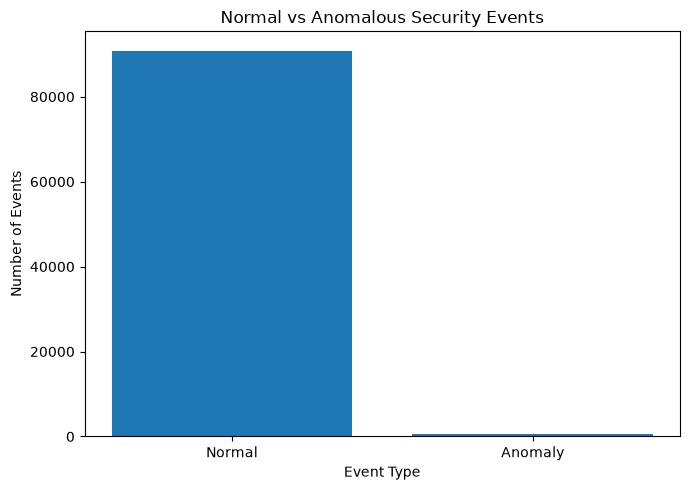

In [28]:
# -------------------------------------------------------------------
# Anomaly distribution visualization
# -------------------------------------------------------------------

anomaly_counts = (
    access_logs["is_anomaly"]
    .value_counts()
    .rename({
        False: "Normal",
        True: "Anomaly"
    })
)

plt.figure(figsize=(7, 5))

plt.bar(
    anomaly_counts.index,
    anomaly_counts.values
)

plt.title("Normal vs Anomalous Security Events")
plt.xlabel("Event Type")
plt.ylabel("Number of Events")

plt.tight_layout()
plt.show()

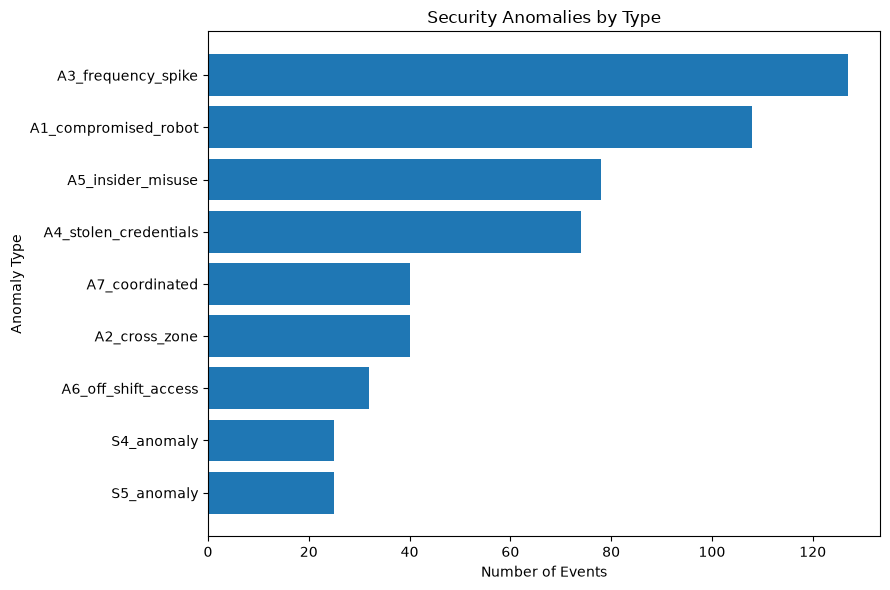

In [29]:
# -------------------------------------------------------------------
# Anomaly type visualization
# -------------------------------------------------------------------

anomaly_type_counts = (
    access_logs.loc[
        access_logs["is_anomaly"],
        "anomaly_type"
    ]
    .value_counts()
    .sort_values()
)

plt.figure(figsize=(9, 6))

plt.barh(
    anomaly_type_counts.index,
    anomaly_type_counts.values
)

plt.title("Security Anomalies by Type")
plt.xlabel("Number of Events")
plt.ylabel("Anomaly Type")

plt.tight_layout()
plt.show()

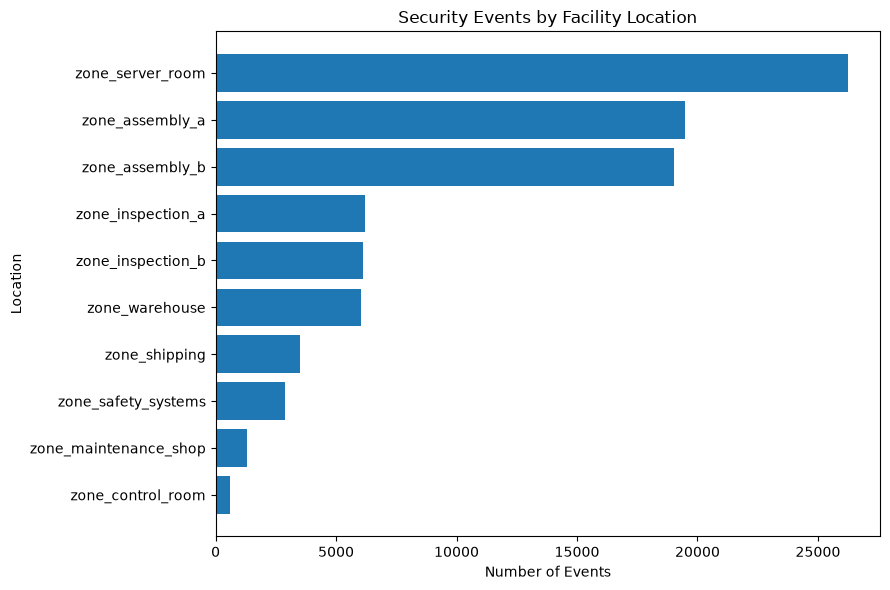

In [30]:
# -------------------------------------------------------------------
# Events by location
# -------------------------------------------------------------------

location_counts = (
    access_logs["location"]
    .value_counts()
    .sort_values()
)

plt.figure(figsize=(9, 6))

plt.barh(
    location_counts.index,
    location_counts.values
)

plt.title("Security Events by Facility Location")
plt.xlabel("Number of Events")
plt.ylabel("Location")

plt.tight_layout()
plt.show()

,anomaly_rate_percent
shift_id,
shift_A,0.53
shift_B,0.55
off_hours,3.36


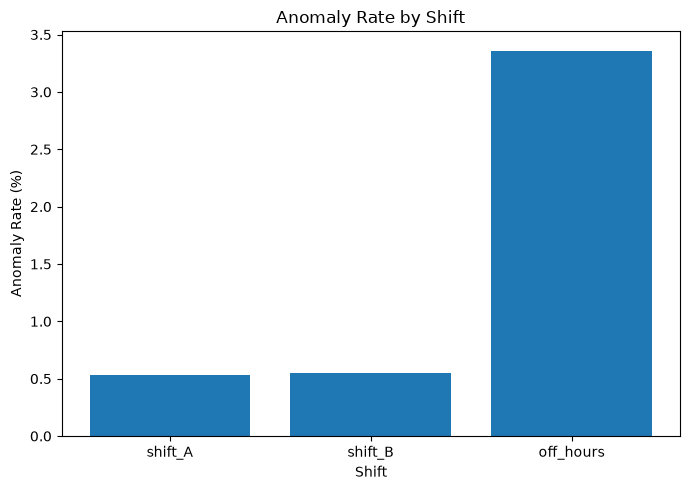

In [31]:
# -------------------------------------------------------------------
# Anomaly rate by shift
# -------------------------------------------------------------------

shift_anomaly_rate = (
    access_logs
    .groupby("shift_id")["is_anomaly"]
    .mean()
    .mul(100)
    .sort_values()
)

display(
    shift_anomaly_rate
    .round(2)
    .to_frame("anomaly_rate_percent")
)

plt.figure(figsize=(7, 5))

plt.bar(
    shift_anomaly_rate.index,
    shift_anomaly_rate.values
)

plt.title("Anomaly Rate by Shift")
plt.xlabel("Shift")
plt.ylabel("Anomaly Rate (%)")

plt.tight_layout()
plt.show()

,anomaly_rate_percent
agent_type,
robot,0.52
human,0.82


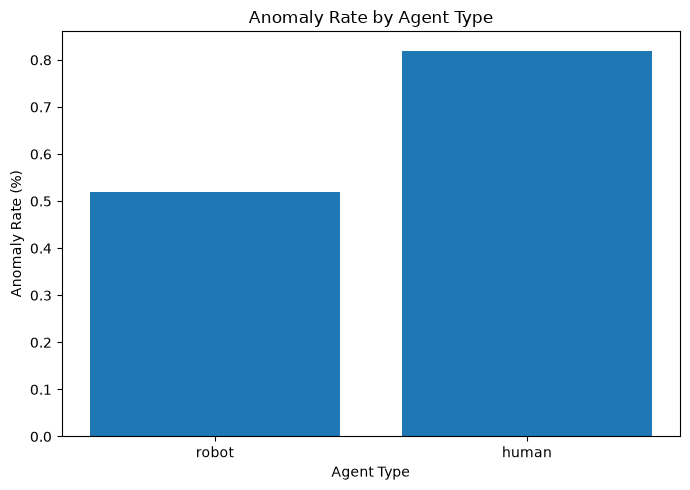

In [32]:
# -------------------------------------------------------------------
# Anomaly rate by agent type
# -------------------------------------------------------------------

agent_anomaly_rate = (
    access_logs
    .groupby("agent_type")["is_anomaly"]
    .mean()
    .mul(100)
    .sort_values()
)

display(
    agent_anomaly_rate
    .round(2)
    .to_frame("anomaly_rate_percent")
)

plt.figure(figsize=(7, 5))

plt.bar(
    agent_anomaly_rate.index,
    agent_anomaly_rate.values
)

plt.title("Anomaly Rate by Agent Type")
plt.xlabel("Agent Type")
plt.ylabel("Anomaly Rate (%)")

plt.tight_layout()
plt.show()

,anomaly_rate_percent
production_state,
active,0.48
changeover,1.19
idle,3.45
e_stop,15.94


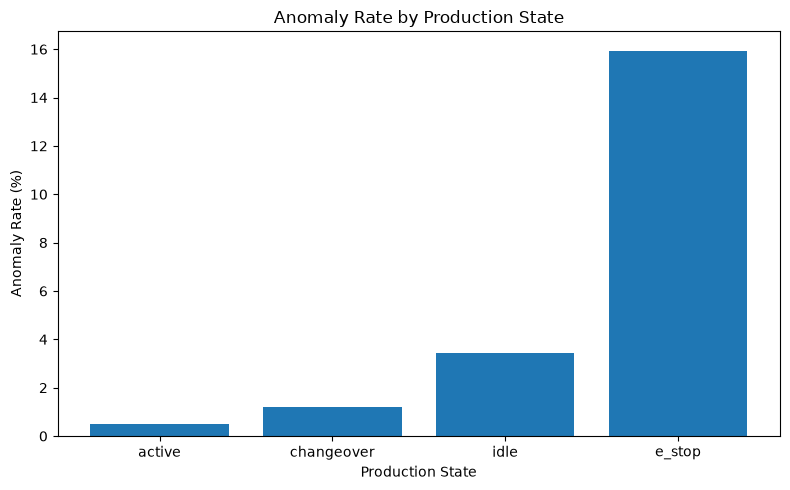

In [33]:
# -------------------------------------------------------------------
# Anomaly rate by production state
# -------------------------------------------------------------------

production_anomaly_rate = (
    access_logs
    .groupby("production_state")["is_anomaly"]
    .mean()
    .mul(100)
    .sort_values()
)

display(
    production_anomaly_rate
    .round(2)
    .to_frame("anomaly_rate_percent")
)

plt.figure(figsize=(8, 5))

plt.bar(
    production_anomaly_rate.index,
    production_anomaly_rate.values
)

plt.title("Anomaly Rate by Production State")
plt.xlabel("Production State")
plt.ylabel("Anomaly Rate (%)")

plt.tight_layout()
plt.show()

,anomaly_rate_percent
location,
zone_safety_systems,0.00
zone_server_room,0.52
zone_maintenance_shop,0.54
zone_assembly_b,0.56
zone_inspection_b,0.59
zone_assembly_a,0.66
zone_inspection_a,0.71
zone_warehouse,0.75
zone_shipping,0.94


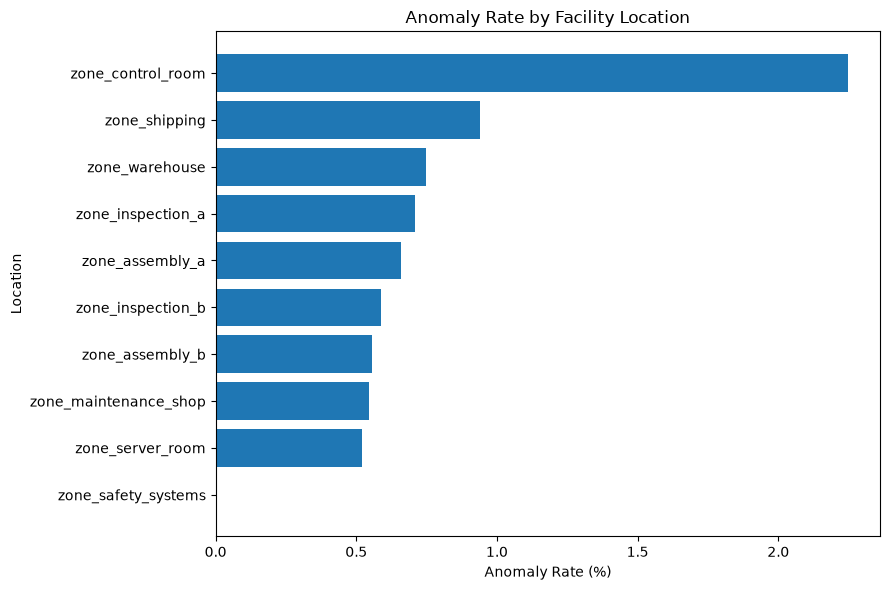

In [34]:
# -------------------------------------------------------------------
# Anomaly rate by location
# -------------------------------------------------------------------

location_anomaly_rate = (
    access_logs
    .groupby("location")["is_anomaly"]
    .mean()
    .mul(100)
    .sort_values()
)

display(
    location_anomaly_rate
    .round(2)
    .to_frame("anomaly_rate_percent")
)

plt.figure(figsize=(9, 6))

plt.barh(
    location_anomaly_rate.index,
    location_anomaly_rate.values
)

plt.title("Anomaly Rate by Facility Location")
plt.xlabel("Anomaly Rate (%)")
plt.ylabel("Location")

plt.tight_layout()
plt.show()

In [35]:
# -------------------------------------------------------------------
# Prepare chronological event data for behavioral analysis
# -------------------------------------------------------------------

security_df = access_logs.copy()

# Ensure chronological ordering
security_df = security_df.sort_values("timestamp").reset_index(drop=True)

print("Security dataframe shape:", security_df.shape)
print("\nTime range:")
print("Start:", security_df["timestamp"].min())
print("End  :", security_df["timestamp"].max())

security_df.head()

Security dataframe shape: (91388, 20)

Time range:
Start: 2026-01-05 00:14:19.091821
End  : 2026-02-01 23:57:59.019816


,log_id,timestamp,session_id,user_id,agent_type,robot_type,human_role,action,resource,resource_type,human_present,emergency_flag,location,previous_action,is_anomaly,anomaly_type,scenario_id,production_state,shift_id,correlation_id
0,log_0000001,2026-01-05 00:14:19.091821,sess_plc_safety_02_00,plc_safety_02,robot,safety_plc,NaN,read_sensor,sensor_emergency_stop_02,sensor,False,False,zone_safety_systems,NaN,False,NaN,NaN,idle,off_hours,NaN
1,log_0000002,2026-01-05 00:14:23.839484,sess_plc_safety_01_00,plc_safety_01,robot,safety_plc,NaN,read_sensor,sensor_emergency_stop_01,sensor,False,False,zone_safety_systems,NaN,False,NaN,NaN,idle,off_hours,NaN
2,log_0000003,2026-01-05 00:28:48.677166,sess_plc_safety_02_00,plc_safety_02,robot,safety_plc,NaN,write_log,database_alerts,database,False,False,zone_server_room,read_sensor,False,NaN,NaN,idle,off_hours,NaN
3,log_0000004,2026-01-05 00:28:57.151507,sess_plc_safety_01_00,plc_safety_01,robot,safety_plc,NaN,write_log,database_alerts,database,False,False,zone_server_room,read_sensor,False,NaN,NaN,idle,off_hours,NaN
4,log_0000005,2026-01-05 00:43:05.385145,sess_plc_safety_02_00,plc_safety_02,robot,safety_plc,NaN,read_sensor,sensor_emergency_stop_02,sensor,False,False,zone_safety_systems,write_log,False,NaN,NaN,idle,off_hours,NaN


In [36]:
security_df.shape

(91388, 20)

In [37]:
# -------------------------------------------------------------------
# Time-based behavioral features
# -------------------------------------------------------------------

security_df["hour"] = security_df["timestamp"].dt.hour
security_df["day_of_week"] = security_df["timestamp"].dt.dayofweek

# Human-readable day name
security_df["day_name"] = security_df["timestamp"].dt.day_name()

# Weekend indicator
security_df["is_weekend"] = security_df["day_of_week"] >= 5

# Facility off-hours
security_df["is_off_hours"] = (
    (security_df["hour"] < 6) |
    (security_df["hour"] >= 22)
)

print("Time-based features added:")
print([
    "hour",
    "day_of_week",
    "day_name",
    "is_weekend",
    "is_off_hours"
])

security_df[
    ["timestamp", "hour", "day_name", "is_weekend", "is_off_hours"]
].head(10)

Time-based features added:
['hour', 'day_of_week', 'day_name', 'is_weekend', 'is_off_hours']


,timestamp,hour,day_name,is_weekend,is_off_hours
0,2026-01-05 00:14:19.091821,0,Monday,False,True
1,2026-01-05 00:14:23.839484,0,Monday,False,True
2,2026-01-05 00:28:48.677166,0,Monday,False,True
3,2026-01-05 00:28:57.151507,0,Monday,False,True
4,2026-01-05 00:43:05.385145,0,Monday,False,True
5,2026-01-05 00:43:29.946491,0,Monday,False,True
6,2026-01-05 00:57:41.135703,0,Monday,False,True
7,2026-01-05 00:57:50.739570,0,Monday,False,True
8,2026-01-05 01:12:02.478589,1,Monday,False,True
9,2026-01-05 01:12:06.801725,1,Monday,False,True


In [38]:
# -------------------------------------------------------------------
# Agent activity frequency
# -------------------------------------------------------------------

security_df = security_df.sort_values(
    ["user_id", "timestamp"]
).reset_index(drop=True)

# Count events generated by each agent within the previous 5 minutes
security_df["events_last_5min"] = (
    security_df
    .set_index("timestamp")
    .groupby("user_id")["log_id"]
    .rolling("5min")
    .count()
    .reset_index(level=0, drop=True)
    .values
)

print("Frequency feature created.")
print("\nSummary:")
print(security_df["events_last_5min"].describe())

security_df[
    ["timestamp", "user_id", "action", "events_last_5min"]
].head(15)

Frequency feature created.

Summary:
count    91388.000000
mean         1.893049
std          1.923023
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         13.000000
Name: events_last_5min, dtype: float64


,timestamp,user_id,action,events_last_5min
0,2026-01-05 06:08:49.528857,human_operator_01,execute_actuator,1.0
1,2026-01-05 06:09:01.821136,human_operator_01,execute_actuator,2.0
2,2026-01-05 06:09:53.216766,human_operator_01,modify_config,3.0
3,2026-01-05 06:10:07.078820,human_operator_01,write_database,4.0
4,2026-01-05 06:10:10.447153,human_operator_01,execute_actuator,5.0
5,2026-01-05 06:10:36.117954,human_operator_01,execute_actuator,6.0
6,2026-01-05 06:10:45.318849,human_operator_01,execute_actuator,7.0
7,2026-01-05 06:10:49.982629,human_operator_01,read_database,8.0
8,2026-01-05 06:10:58.326294,human_operator_01,read_sensor,9.0
9,2026-01-05 07:36:00.000000,human_operator_01,execute_actuator,1.0


In [39]:
# -------------------------------------------------------------------
# Inspect agent activity frequency
# -------------------------------------------------------------------

print("Events per agent in a 5-minute window:")
print(security_df["events_last_5min"].describe())

print("\nHighest observed activity windows:")
print(
    security_df[
        ["timestamp", "user_id", "action", "events_last_5min"]
    ]
    .sort_values("events_last_5min", ascending=False)
    .head(10)
)

Events per agent in a 5-minute window:
count    91388.000000
mean         1.893049
std          1.923023
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         13.000000
Name: events_last_5min, dtype: float64

Highest observed activity windows:
                       timestamp              user_id            action  events_last_5min
9402  2026-01-26 06:17:25.402056    human_operator_09       read_sensor              13.0
9405  2026-01-26 06:18:22.709956    human_operator_09     read_database              12.0
17594 2026-01-26 16:04:50.281901  human_supervisor_03  execute_actuator              12.0
9401  2026-01-26 06:16:07.183849    human_operator_09       read_sensor              12.0
9079  2026-01-17 06:15:01.365136    human_operator_09     read_database              11.0
15403 2026-01-18 08:04:01.355406  human_supervisor_01       read_sensor              11.0
4652  2026-01-08 07:39:39.572628    human_operator_05     modify_config         

In [40]:
# -------------------------------------------------------------------
# Compare activity frequency for normal vs anomalous events
# -------------------------------------------------------------------

frequency_comparison = (
    security_df
    .groupby("is_anomaly")["events_last_5min"]
    .agg(["count", "mean", "median", "max"])
    .rename(index={
        False: "Normal",
        True: "Anomaly"
    })
)

frequency_comparison

,count,mean,median,max
is_anomaly,,,,
Normal,90839,1.890344,1.0,13.0
Anomaly,549,2.340619,2.0,7.0


<Figure size 1000x600 with 0 Axes>

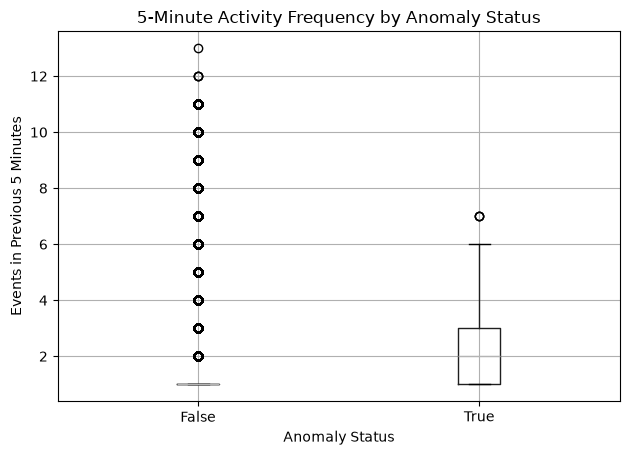

In [41]:
# -------------------------------------------------------------------
# Activity frequency distribution by anomaly status
# -------------------------------------------------------------------

plt.figure(figsize=(10, 6))

security_df.boxplot(
    column="events_last_5min",
    by="is_anomaly"
)

plt.title("5-Minute Activity Frequency by Anomaly Status")
plt.suptitle("")
plt.xlabel("Anomaly Status")
plt.ylabel("Events in Previous 5 Minutes")
plt.tight_layout()
plt.show()

In [42]:
# -------------------------------------------------------------------
# Inspect agent authorization profiles
# -------------------------------------------------------------------

print("Number of agent profiles:", len(agent_profiles))

print("\nFirst agent profile:")
agent_profiles[0]

Number of agent profiles: 67

First agent profile:


{'entity_id': 'robot_assembly_01',
 'entity_type': 'robot',
 'subtype': 'assembly_robot',
 'home_zone': 'zone_assembly_a',
 'shift': 'production_hours',
 'authorized_resources': ['actuator_arm_a1',
  'actuator_arm_a2',
  'sensor_force_a1',
  'sensor_force_a2',
  'sensor_motion_a1',
  'tool_gripper_a1',
  'tool_gripper_a2',
  'database_production_log',
  'actuator_arm_b1',
  'actuator_arm_b2',
  'sensor_force_b1',
  'sensor_force_b2',
  'sensor_motion_b1',
  'tool_gripper_b1',
  'tool_gripper_b2'],
 'typical_resources': ['actuator_arm_a1',
  'actuator_arm_a2',
  'sensor_force_a1',
  'sensor_force_a2',
  'sensor_motion_a1',
  'tool_gripper_a1',
  'tool_gripper_a2',
  'database_production_log'],
 'safety_critical': False,
 'task_program': ['read_sensor',
  'execute_actuator',
  'read_sensor',
  'write_log'],
 'cycle_time': {'distribution': 'gamma',
  'params': {'shape': 47.265625, 'loc': 11.25, 'scale': 0.2909090909090909},
  'mean_seconds': 25.0,
  'std_seconds': 2.0,
  'source': 'litera

In [43]:
# -------------------------------------------------------------------
# Build agent authorization mapping
# -------------------------------------------------------------------

authorization_map = {
    profile["entity_id"]: set(profile.get("authorized_resources", []))
    for profile in agent_profiles
}

print("Agents in authorization map:", len(authorization_map))

# Show one example
example_agent = agent_profiles[0]["entity_id"]

print("\nExample agent:", example_agent)
print("Authorized resources:")
print(authorization_map[example_agent])

Agents in authorization map: 67

Example agent: robot_assembly_01
Authorized resources:
{'sensor_force_a1', 'tool_gripper_b1', 'actuator_arm_b2', 'sensor_motion_a1', 'actuator_arm_a1', 'database_production_log', 'sensor_force_b1', 'sensor_motion_b1', 'sensor_force_a2', 'tool_gripper_b2', 'sensor_force_b2', 'actuator_arm_b1', 'tool_gripper_a1', 'actuator_arm_a2', 'tool_gripper_a2'}


In [44]:
# -------------------------------------------------------------------
# Authorization mismatch feature
# -------------------------------------------------------------------

security_df["authorization_mismatch"] = security_df.apply(
    lambda row: (
        row["resource"] not in authorization_map.get(row["user_id"], set())
    ),
    axis=1
)

print("Authorization mismatch feature created.")

print("\nAuthorization status:")
print(
    security_df["authorization_mismatch"]
    .value_counts()
    .rename({
        False: "Authorized",
        True: "Unauthorized"
    })
)

print("\nSample events:")
print(
    security_df[
        ["timestamp", "user_id", "resource", "authorization_mismatch"]
    ].head(15)
)

Authorization mismatch feature created.

Authorization status:
authorization_mismatch
Authorized      91298
Unauthorized       90
Name: count, dtype: int64

Sample events:
                    timestamp            user_id                 resource  authorization_mismatch
0  2026-01-05 06:08:49.528857  human_operator_01          tool_gripper_a1                   False
1  2026-01-05 06:09:01.821136  human_operator_01          tool_gripper_a1                   False
2  2026-01-05 06:09:53.216766  human_operator_01          actuator_arm_a1                   False
3  2026-01-05 06:10:07.078820  human_operator_01  database_production_log                   False
4  2026-01-05 06:10:10.447153  human_operator_01          actuator_arm_a2                   False
5  2026-01-05 06:10:36.117954  human_operator_01          actuator_arm_a2                   False
6  2026-01-05 06:10:45.318849  human_operator_01          actuator_arm_a2                   False
7  2026-01-05 06:10:49.982629  human_operato

In [45]:
# -------------------------------------------------------------------
# Evaluate authorization mismatch against known anomaly labels
# -------------------------------------------------------------------

authorization_comparison = (
    security_df
    .groupby("authorization_mismatch")["is_anomaly"]
    .agg(["count", "sum", "mean"])
)

authorization_comparison.index = [
    "Authorized",
    "Unauthorized"
]

authorization_comparison.columns = [
    "Total Events",
    "Anomalous Events",
    "Anomaly Rate"
]

authorization_comparison

,Total Events,Anomalous Events,Anomaly Rate
Authorized,91298,484,0.005301
Unauthorized,90,65,0.722222


In [46]:
# -------------------------------------------------------------------
# Inspect unauthorized access events
# -------------------------------------------------------------------

unauthorized_events = security_df[
    security_df["authorization_mismatch"]
].copy()

print("Unauthorized events:", len(unauthorized_events))

print("\nUnauthorized events by anomaly status:")
print(
    unauthorized_events["is_anomaly"]
    .value_counts()
    .rename({
        False: "Normal",
        True: "Anomaly"
    })
)

print("\nUnauthorized events by action:")
print(
    unauthorized_events["action"]
    .value_counts()
)

print("\nUnauthorized events by resource:")
print(
    unauthorized_events["resource"]
    .value_counts().head(20)
)

Unauthorized events: 90

Unauthorized events by anomaly status:
is_anomaly
Anomaly    65
Normal     25
Name: count, dtype: int64

Unauthorized events by action:
action
read_sensor         34
write_database      25
access_resource     11
execute_actuator    10
capture_image        6
move                 4
Name: count, dtype: int64

Unauthorized events by resource:
resource
database_inventory             25
sensor_emergency_stop_02       14
sensor_emergency_stop_01       11
workstation_supervisor_02       8
tool_diagnostic_kit_02          5
camera_mount_s1                 3
workstation_supervisor_01       3
sensor_inventory_scanner_02     2
tool_gripper_a2                 2
sensor_vision_a2                2
agv_dock_shipping               2
sensor_dimension_b1             2
sensor_dimension_a1             1
camera_mount_ia2                1
agv_dock_inspection_a           1
camera_mount_ib1                1
camera_mount_w1                 1
tool_pallet_lift_01             1
agv_dock_ware

In [47]:
# -------------------------------------------------------------------
# Home-zone mismatch analysis
# -------------------------------------------------------------------

home_zone_map = {
    profile["entity_id"]: profile.get("home_zone")
    for profile in agent_profiles
}

security_df["home_zone"] = security_df["user_id"].map(home_zone_map)

# Compare home zone directly with the logged location
security_df["home_zone_mismatch"] = (
    security_df["home_zone"] != security_df["location"]
)

# Missing home-zone information should not be treated as a mismatch
security_df.loc[
    security_df["home_zone"].isna(),
    "home_zone_mismatch"
] = False

print("Home-zone information available for:",
      security_df["home_zone"].notna().sum(),
      "events")

print("\nHome-zone mismatch:")
print(security_df["home_zone_mismatch"].value_counts())

print("\nSample home-zone mismatch events:")

security_df[
    security_df["home_zone_mismatch"]
][[
    "user_id",
    "agent_type",
    "home_zone",
    "location",
    "action",
    "resource",
    "is_anomaly"
]].head(20)

Home-zone information available for: 91388 events

Home-zone mismatch:
home_zone_mismatch
False    58048
True     33340
Name: count, dtype: int64

Sample home-zone mismatch events:


,user_id,agent_type,home_zone,location,action,resource,is_anomaly
3,human_operator_01,human,zone_assembly_a,zone_server_room,write_database,database_production_log,False
7,human_operator_01,human,zone_assembly_a,zone_server_room,read_database,database_production_log,False
15,human_operator_01,human,zone_assembly_a,zone_server_room,read_database,database_production_log,False
28,human_operator_01,human,zone_assembly_a,zone_server_room,read_database,database_production_log,False
31,human_operator_01,human,zone_assembly_a,zone_server_room,read_database,database_production_log,False
32,human_operator_01,human,zone_assembly_a,zone_server_room,read_database,database_production_log,False
43,human_operator_01,human,zone_assembly_a,zone_server_room,read_database,database_production_log,False
44,human_operator_01,human,zone_assembly_a,zone_server_room,read_database,database_production_log,False
46,human_operator_01,human,zone_assembly_a,zone_server_room,read_database,database_production_log,False
48,human_operator_01,human,zone_assembly_a,zone_assembly_b,read_sensor,sensor_force_b2,False


In [48]:
# -------------------------------------------------------------------
# Evaluate home-zone mismatch against anomaly labels
# -------------------------------------------------------------------

home_zone_comparison = (
    security_df
    .groupby("home_zone_mismatch")["is_anomaly"]
    .agg(["count", "sum", "mean"])
)

home_zone_comparison.index = [
    "Home Zone",
    "Outside Home Zone"
]

home_zone_comparison.columns = [
    "Total Events",
    "Anomalous Events",
    "Anomaly Rate"
]

home_zone_comparison

,Total Events,Anomalous Events,Anomaly Rate
Home Zone,58048,157,0.002705
Outside Home Zone,33340,392,0.011758


In [49]:
# -------------------------------------------------------------------
# Action sequence analysis
# -------------------------------------------------------------------

security_df["action_transition"] = (
    security_df["previous_action"].fillna("NONE")
    + " -> "
    + security_df["action"]
)

print("Unique action transitions:",
      security_df["action_transition"].nunique())

print("\nMost common action transitions:")
print(
    security_df["action_transition"]
    .value_counts()
    .head(20)
)

Unique action transitions: 85

Most common action transitions:
action_transition
read_sensor -> write_log                14149
write_log -> read_sensor                 9820
execute_actuator -> read_sensor          9246
read_sensor -> execute_actuator          9239
write_log -> move                        8068
move -> move                             6762
move -> read_sensor                      4351
move -> capture_image                    3711
capture_image -> write_log               3710
execute_actuator -> execute_actuator     3560
read_sensor -> read_sensor               3531
read_sensor -> read_database             2162
read_database -> read_sensor             2147
execute_actuator -> read_database        1742
read_database -> execute_actuator        1735
read_database -> read_database           1666
write_database -> read_sensor             572
write_log -> write_log                    563
read_sensor -> write_database             529
read_database -> write_database           431

In [50]:
# -------------------------------------------------------------------
# Evaluate action transitions against anomaly labels
# -------------------------------------------------------------------

transition_analysis = (
    security_df
    .groupby("action_transition")["is_anomaly"]
    .agg(["count", "sum", "mean"])
    .rename(columns={
        "count": "Total Events",
        "sum": "Anomalous Events",
        "mean": "Anomaly Rate"
    })
)

# Show transitions with at least 10 occurrences
# to avoid interpreting extremely rare transitions too strongly.
transition_analysis_filtered = (
    transition_analysis[
        transition_analysis["Total Events"] >= 10
    ]
    .sort_values(
        ["Anomaly Rate", "Total Events"],
        ascending=[False, False]
    )
)

print("Transitions with at least 10 occurrences:")
transition_analysis_filtered.head(20)

Transitions with at least 10 occurrences:


,Total Events,Anomalous Events,Anomaly Rate
action_transition,,,
write_log -> write_database,13,13,1.000000
write_log -> capture_image,11,5,0.454545
read_sensor -> move,23,10,0.434783
write_log -> execute_actuator,25,10,0.400000
capture_image -> move,10,4,0.400000
move -> write_log,50,16,0.320000
execute_actuator -> write_log,21,6,0.285714
modify_config -> modify_config,18,4,0.222222
write_database -> modify_config,24,2,0.083333


In [51]:
# -------------------------------------------------------------------
# Action transition frequency and rarity
# -------------------------------------------------------------------

transition_counts = (
    security_df["action_transition"]
    .value_counts()
)

security_df["transition_count"] = (
    security_df["action_transition"]
    .map(transition_counts)
)

security_df["transition_rarity"] = (
    1 / security_df["transition_count"]
)

print("Transition count statistics:")
print(
    security_df["transition_count"].describe()
)

print("\nTransition rarity statistics:")
print(
    security_df["transition_rarity"].describe()
)

print("\nRarest transitions:")
print(
    transition_counts
    .sort_values()
    .head(15)
)

Transition count statistics:
count    91388.000000
mean      7330.259465
std       4173.852905
min          1.000000
25%       3710.000000
50%       8068.000000
75%       9820.000000
max      14149.000000
Name: transition_count, dtype: float64

Transition rarity statistics:
count    91388.000000
mean         0.000930
std          0.011967
min          0.000071
25%          0.000102
50%          0.000124
75%          0.000270
max          1.000000
Name: transition_rarity, dtype: float64

Rarest transitions:
action_transition
access_resource -> capture_image     1
NONE -> access_workstation           1
NONE -> modify_config                1
capture_image -> execute_actuator    1
write_database -> approve            1
modify_config -> approve             1
read_sensor -> access_resource       2
write_log -> access_resource         2
capture_image -> access_resource     2
access_resource -> read_sensor       2
NONE -> write_database               3
capture_image -> read_sensor         3
re

In [52]:
# -------------------------------------------------------------------
# Stable transition-frequency features
# -------------------------------------------------------------------

security_df["transition_log_frequency"] = (
    np.log1p(security_df["transition_count"])
)

security_df["transition_is_rare"] = (
    security_df["transition_count"] <= 10
)

print("Transition log-frequency statistics:")
print(
    security_df["transition_log_frequency"].describe()
)

print("\nRare transitions (frequency <= 10):",
      security_df["transition_is_rare"].sum())

print("\nAnomaly rate for rare transitions:")
print(
    security_df[
        security_df["transition_is_rare"]
    ]["is_anomaly"].mean()
)

Transition log-frequency statistics:
count    91388.000000
mean         8.589162
std          1.041616
min          0.693147
25%          8.219057
50%          8.995785
75%          9.192278
max          9.557470
Name: transition_log_frequency, dtype: float64

Rare transitions (frequency <= 10): 144

Anomaly rate for rare transitions:
0.1736111111111111


In [53]:
# -------------------------------------------------------------------
# Evaluate off-hours activity against anomaly labels
# -------------------------------------------------------------------

off_hours_comparison = (
    security_df
    .groupby("is_off_hours")["is_anomaly"]
    .agg(["count", "sum", "mean"])
)

off_hours_comparison.index = [
    "Regular Hours",
    "Off Hours"
]

off_hours_comparison.columns = [
    "Total Events",
    "Anomalous Events",
    "Anomaly Rate"
]

off_hours_comparison


,Total Events,Anomalous Events,Anomaly Rate
Regular Hours,89424,483,0.005401
Off Hours,1964,66,0.033605


In [54]:
# -------------------------------------------------------------------
# Combined security indicators
# -------------------------------------------------------------------

security_df["multiple_security_signals"] = (
    security_df["authorization_mismatch"].astype(int)
    + security_df["home_zone_mismatch"].astype(int)
    + security_df["is_off_hours"].astype(int)
    + security_df["transition_is_rare"].astype(int)
)

combined_analysis = (
    security_df
    .groupby("multiple_security_signals")["is_anomaly"]
    .agg(["count", "sum", "mean"])
)

combined_analysis.columns = [
    "Total Events",
    "Anomalous Events",
    "Anomaly Rate"
]

combined_analysis

,Total Events,Anomalous Events,Anomaly Rate
multiple_security_signals,,,
0,57040,145,0.002542
1,33178,280,0.008439
2,1150,104,0.090435
3,20,20,1.000000


In [55]:
# -------------------------------------------------------------------
# Security feature summary
# -------------------------------------------------------------------

security_features = [
    "events_last_5min",
    "authorization_mismatch",
    "home_zone_mismatch",
    "is_off_hours",
    "transition_count",
    "transition_log_frequency",
    "transition_is_rare"
]

security_df[security_features].describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
events_last_5min,91388.0,NaN,NaN,NaN,1.893049,1.923023,1.0,1.0,1.0,1.0,13.0
authorization_mismatch,91388,2,False,91298,NaN,NaN,NaN,NaN,NaN,NaN,NaN
home_zone_mismatch,91388,2,False,58048,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_off_hours,91388,2,False,89424,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transition_count,91388.0,NaN,NaN,NaN,7330.259465,4173.852905,1.0,3710.0,8068.0,9820.0,14149.0
transition_log_frequency,91388.0,NaN,NaN,NaN,8.589162,1.041616,0.693147,8.219057,8.995785,9.192278,9.55747
transition_is_rare,91388,2,False,91244,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [56]:
# -------------------------------------------------------------------
# Prepare security detection features
# -------------------------------------------------------------------

security_feature_columns = [
    "events_last_5min",
    "authorization_mismatch",
    "home_zone_mismatch",
    "is_off_hours",
    "transition_log_frequency",
    "transition_is_rare",
    "human_present",
    "emergency_flag"
]

X = security_df[security_feature_columns].copy()
y = security_df["is_anomaly"].astype(int)

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget distribution:")
print(y.value_counts())

print("\nTarget percentage:")
print(y.value_counts(normalize=True))

Feature matrix shape: (91388, 8)
Target shape: (91388,)

Features:
['events_last_5min', 'authorization_mismatch', 'home_zone_mismatch', 'is_off_hours', 'transition_log_frequency', 'transition_is_rare', 'human_present', 'emergency_flag']

Target distribution:
is_anomaly
0    90839
1      549
Name: count, dtype: int64

Target percentage:
is_anomaly
0    0.993993
1    0.006007
Name: proportion, dtype: float64


In [57]:
# -------------------------------------------------------------------
# Chronological train / validation / test split
# -------------------------------------------------------------------

security_df = security_df.sort_values("timestamp").reset_index(drop=True)

n = len(security_df)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = security_df.iloc[:train_end].copy()
val_df = security_df.iloc[train_end:val_end].copy()
test_df = security_df.iloc[val_end:].copy()

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

print("\nTime ranges:")
print("Train:", train_df["timestamp"].min(), "→", train_df["timestamp"].max())
print("Validation:", val_df["timestamp"].min(), "→", val_df["timestamp"].max())
print("Test:", test_df["timestamp"].min(), "→", test_df["timestamp"].max())

print("\nAnomaly distribution:")
print("Train:")
print(train_df["is_anomaly"].value_counts())

print("\nValidation:")
print(val_df["is_anomaly"].value_counts())

print("\nTest:")
print(test_df["is_anomaly"].value_counts())

Train shape: (63971, 35)
Validation shape: (13708, 35)
Test shape: (13709, 35)

Time ranges:
Train: 2026-01-05 00:14:19.091821 → 2026-01-24 14:00:40.345446
Validation: 2026-01-24 14:00:48.677011 → 2026-01-28 17:25:01.449520
Test: 2026-01-28 17:25:05.808078 → 2026-02-01 23:57:59.019816

Anomaly distribution:
Train:
is_anomaly
False    63732
True       239
Name: count, dtype: int64

Validation:
is_anomaly
False    13552
True       156
Name: count, dtype: int64

Test:
is_anomaly
False    13555
True       154
Name: count, dtype: int64


In [58]:
# -------------------------------------------------------------------
# Recalculate transition-frequency features using TRAINING data only
# -------------------------------------------------------------------

train_transition_counts = train_df["action_transition"].value_counts()

def add_transition_features(df):
    df = df.copy()

    df["transition_count_train"] = (
        df["action_transition"]
        .map(train_transition_counts)
        .fillna(0)
    )

    df["transition_log_frequency_train"] = np.log1p(
        df["transition_count_train"]
    )

    df["transition_is_rare_train"] = (
        df["transition_count_train"] <= 10
    )

    return df


train_df = add_transition_features(train_df)
val_df = add_transition_features(val_df)
test_df = add_transition_features(test_df)

print("Train transition features:")
print(
    train_df[
        [
            "transition_count_train",
            "transition_log_frequency_train",
            "transition_is_rare_train"
        ]
    ].describe()
)

print("\nUnseen transitions in validation:",
      (val_df["transition_count_train"] == 0).sum())

print("Unseen transitions in test:",
      (test_df["transition_count_train"] == 0).sum())

Train transition features:
       transition_count_train  transition_log_frequency_train
count            63971.000000                    63971.000000
mean              5099.666740                        8.228280
std               2907.722427                        1.035932
min                  1.000000                        0.693147
25%               2580.000000                        7.855932
50%               5616.000000                        8.633553
75%               6835.000000                        8.829958
max               9863.000000                        9.196647

Unseen transitions in validation: 1
Unseen transitions in test: 0


In [59]:
# -------------------------------------------------------------------
# Build final feature matrices
# -------------------------------------------------------------------

final_feature_columns = [
    "events_last_5min",
    "authorization_mismatch",
    "home_zone_mismatch",
    "is_off_hours",
    "transition_log_frequency_train",
    "transition_is_rare_train",
    "human_present",
    "emergency_flag"
]

X_train = train_df[final_feature_columns].copy()
y_train = train_df["is_anomaly"].astype(int)

X_val = val_df[final_feature_columns].copy()
y_val = val_df["is_anomaly"].astype(int)

X_test = test_df[final_feature_columns].copy()
y_test = test_df["is_anomaly"].astype(int)

print("Final feature columns:")
print(final_feature_columns)

print("\nShapes:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val  :", X_val.shape)
print("y_val  :", y_val.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

print("\nMissing values:")
print("Train:", X_train.isna().sum().sum())
print("Validation:", X_val.isna().sum().sum())
print("Test:", X_test.isna().sum().sum())

Final feature columns:
['events_last_5min', 'authorization_mismatch', 'home_zone_mismatch', 'is_off_hours', 'transition_log_frequency_train', 'transition_is_rare_train', 'human_present', 'emergency_flag']

Shapes:
X_train: (63971, 8)
y_train: (63971,)
X_val  : (13708, 8)
y_val  : (13708,)
X_test : (13709, 8)
y_test : (13709,)

Missing values:
Train: 0
Validation: 0
Test: 0


In [60]:
# -------------------------------------------------------------------
# Train Security Anomaly Detector
# -------------------------------------------------------------------

from sklearn.ensemble import RandomForestClassifier

security_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=3,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

print("Training Security Anomaly Detector...")

security_model.fit(X_train, y_train)

print("Training completed.")

Training Security Anomaly Detector...
Training completed.


In [61]:
# -------------------------------------------------------------------
# Generate validation predictions and anomaly probabilities
# -------------------------------------------------------------------

y_val_proba = security_model.predict_proba(X_val)[:, 1]
y_val_pred_default = (y_val_proba >= 0.50).astype(int)

print("Validation predictions generated.")

print("\nPredicted anomaly count (threshold = 0.50):",
      y_val_pred_default.sum())

print("Actual anomaly count:",
      y_val.sum())

print("\nProbability statistics:")
print(pd.Series(y_val_proba).describe())

Validation predictions generated.

Predicted anomaly count (threshold = 0.50): 1324
Actual anomaly count: 156

Probability statistics:
count    13708.000000
mean         0.161733
std          0.205385
min          0.008560
25%          0.043265
50%          0.071158
75%          0.157102
max          0.999159
dtype: float64


In [62]:
# -------------------------------------------------------------------
# Evaluate different anomaly-alert thresholds on validation data
# -------------------------------------------------------------------

from sklearn.metrics import precision_score, recall_score, f1_score

threshold_results = []

for threshold in np.arange(0.05, 1.00, 0.05):
    y_pred = (y_val_proba >= threshold).astype(int)

    precision = precision_score(y_val, y_pred, zero_division=0)
    recall = recall_score(y_val, y_pred, zero_division=0)
    f1 = f1_score(y_val, y_pred, zero_division=0)

    threshold_results.append({
        "threshold": round(threshold, 2),
        "alerts": int(y_pred.sum()),
        "precision": precision,
        "recall": recall,
        "f1": f1
    })

threshold_results_df = pd.DataFrame(threshold_results)

print(threshold_results_df.to_string(index=False))

 threshold  alerts  precision   recall       f1
      0.05    9689   0.015998 0.993590 0.031488
      0.10    5584   0.026325 0.942308 0.051220
      0.15    4516   0.031444 0.910256 0.060788
      0.20    3070   0.044300 0.871795 0.084315
      0.25    2684   0.049553 0.852564 0.093662
      0.30    2314   0.056180 0.833333 0.105263
      0.35    2151   0.059972 0.826923 0.111834
      0.40    1968   0.065549 0.826923 0.121469
      0.45    1452   0.085399 0.794872 0.154229
      0.50    1324   0.092145 0.782051 0.164865
      0.55    1095   0.111416 0.782051 0.195044
      0.60     875   0.137143 0.769231 0.232784
      0.65     765   0.154248 0.756410 0.256243
      0.70     605   0.183471 0.711538 0.291721
      0.75     393   0.279898 0.705128 0.400729
      0.80     262   0.396947 0.666667 0.497608
      0.85     205   0.487805 0.641026 0.554017
      0.90     123   0.731707 0.576923 0.645161
      0.95      95   0.778947 0.474359 0.589641


In [63]:
# -------------------------------------------------------------------
# Detailed validation evaluation
# -------------------------------------------------------------------

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    average_precision_score,
    roc_auc_score
)

validation_threshold = 0.90

y_val_pred = (y_val_proba >= validation_threshold).astype(int)

print("Validation threshold:", validation_threshold)

print("\nClassification Report:")
print(
    classification_report(
        y_val,
        y_val_pred,
        target_names=["Normal", "Anomaly"],
        zero_division=0
    )
)

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred))

print("\nPR-AUC:", average_precision_score(y_val, y_val_proba))
print("ROC-AUC:", roc_auc_score(y_val, y_val_proba))

print("\nAlerts generated:", y_val_pred.sum())
print("Actual anomalies:", y_val.sum())

Validation threshold: 0.9

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     13552
     Anomaly       0.73      0.58      0.65       156

    accuracy                           0.99     13708
   macro avg       0.86      0.79      0.82     13708
weighted avg       0.99      0.99      0.99     13708


Confusion Matrix:
[[13519    33]
 [   66    90]]

PR-AUC: 0.598234755118811
ROC-AUC: 0.9220812331607785

Alerts generated: 123
Actual anomalies: 156


In [64]:
# -------------------------------------------------------------------
# Final evaluation on the untouched test set
# -------------------------------------------------------------------

y_test_proba = security_model.predict_proba(X_test)[:, 1]

# Use threshold selected from validation data
security_threshold = 0.90

y_test_pred = (
    y_test_proba >= security_threshold
).astype(int)

print("Test threshold:", security_threshold)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=["Normal", "Anomaly"],
        zero_division=0
    )
)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

print("\nPR-AUC:", average_precision_score(y_test, y_test_proba))
print("ROC-AUC:", roc_auc_score(y_test, y_test_proba))

print("\nAlerts generated:", y_test_pred.sum())
print("Actual anomalies:", y_test.sum())

Test threshold: 0.9

Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      1.00      1.00     13555
     Anomaly       0.60      0.42      0.49       154

    accuracy                           0.99     13709
   macro avg       0.80      0.71      0.74     13709
weighted avg       0.99      0.99      0.99     13709


Confusion Matrix:
[[13513    42]
 [   90    64]]

PR-AUC: 0.4562088602025957
ROC-AUC: 0.9085658716053404

Alerts generated: 106
Actual anomalies: 154


In [65]:
# -------------------------------------------------------------------
# Security detector feature importance
# -------------------------------------------------------------------

feature_importance = pd.DataFrame({
    "feature": final_feature_columns,
    "importance": security_model.feature_importances_
}).sort_values(
    "importance",
    ascending=False
).reset_index(drop=True)

print("Security detector feature importance:")
print(feature_importance.to_string(index=False))

Security detector feature importance:
                       feature  importance
transition_log_frequency_train    0.396696
              events_last_5min    0.281796
            home_zone_mismatch    0.100724
                 human_present    0.082377
        authorization_mismatch    0.051795
                  is_off_hours    0.049479
                emergency_flag    0.020624
      transition_is_rare_train    0.016508


In [66]:
# -------------------------------------------------------------------
# Save trained Security Anomaly Detector
# -------------------------------------------------------------------

import os
import json
import joblib

security_models_dir = "../models"
os.makedirs(security_models_dir, exist_ok=True)

model_path = os.path.join(
    security_models_dir,
    "security_anomaly_random_forest.joblib"
)

metadata_path = os.path.join(
    security_models_dir,
    "security_model_metadata.json"
)

# Save trained model
joblib.dump(security_model, model_path)

# Save model configuration
security_model_metadata = {
    "model_type": "RandomForestClassifier",
    "threshold": security_threshold,
    "features": final_feature_columns,
    "n_estimators": 200,
    "max_depth": 12,
    "min_samples_leaf": 3,
    "class_weight": "balanced",
    "random_state": 42,
    "validation_metrics": {
        "precision": 0.731707,
        "recall": 0.576923,
        "f1": 0.645161,
        "pr_auc": 0.598235,
        "roc_auc": 0.922081
    },
    "test_metrics": {
        "precision": 0.603774,
        "recall": 0.415584,
        "f1": 0.492308,
        "pr_auc": 0.456209,
        "roc_auc": 0.908566
    }
}

with open(metadata_path, "w") as f:
    json.dump(
        security_model_metadata,
        f,
        indent=4
    )

print("Security model saved:")
print(model_path)

print("\nMetadata saved:")
print(metadata_path)

print("\nFiles in models directory:")
print(os.listdir(security_models_dir))

Security model saved:
../models\security_anomaly_random_forest.joblib

Metadata saved:
../models\security_model_metadata.json

Files in models directory:
['security_anomaly_random_forest.joblib', 'security_model_metadata.json', 'security_transition_frequency.json']


In [67]:
# -------------------------------------------------------------------
# Verify saved model can be loaded successfully
# -------------------------------------------------------------------

loaded_security_model = joblib.load(model_path)

with open(metadata_path, "r") as f:
    loaded_metadata = json.load(f)

print("Model loaded successfully:", type(loaded_security_model).__name__)

print("\nLoaded threshold:")
print(loaded_metadata["threshold"])

print("\nLoaded features:")
print(loaded_metadata["features"])

# Verify predictions from the saved model
loaded_test_proba = loaded_security_model.predict_proba(X_test)[:, 1]

print("\nPrediction consistency check:")
print(
    "Maximum probability difference:",
    np.max(np.abs(y_test_proba - loaded_test_proba))
)

Model loaded successfully: RandomForestClassifier

Loaded threshold:
0.9

Loaded features:
['events_last_5min', 'authorization_mismatch', 'home_zone_mismatch', 'is_off_hours', 'transition_log_frequency_train', 'transition_is_rare_train', 'human_present', 'emergency_flag']

Prediction consistency check:
Maximum probability difference: 2.220446049250313e-16


In [68]:
# Cell 68 — Test SecurityDetector

import sys
from pathlib import Path

security_src = Path.cwd().resolve().parent / "src"

if str(security_src) not in sys.path:
    sys.path.insert(0, str(security_src))

from security_detector import SecurityDetector

# Load trained detector
detector = SecurityDetector()

print("Detector loaded successfully.")
print("Model:", type(detector.model).__name__)
print("Threshold:", detector.threshold)
print("Features:", detector.features)

Detector loaded successfully.
Model: RandomForestClassifier
Threshold: 0.9
Features: ['events_last_5min', 'authorization_mismatch', 'home_zone_mismatch', 'is_off_hours', 'transition_log_frequency_train', 'transition_is_rare_train', 'human_present', 'emergency_flag']


In [69]:
# Cell 69 — Test SecurityDetector prediction

sample_event_features = {
    "events_last_5min": 3,
    "authorization_mismatch": True,
    "home_zone_mismatch": True,
    "is_off_hours": True,
    "transition_log_frequency_train": 1.0,
    "transition_is_rare_train": True,
    "human_present": True,
    "emergency_flag": False
}

result = detector.predict(sample_event_features)

print("Prediction result:")
print(result)

print("\nRisk score:", round(result["risk_score"], 4))
print("Anomaly detected:", result["is_anomaly"])
print("Decision threshold:", result["threshold"])

Prediction result:
{'risk_score': 0.709632958628824, 'is_anomaly': False, 'threshold': 0.9}

Risk score: 0.7096
Anomaly detected: False
Decision threshold: 0.9


In [70]:
# Cell 70 — Save training transition frequencies

import json
from pathlib import Path

security_models_dir = (
    Path.cwd().resolve().parent / "models"
)

transition_frequency_path = (
    security_models_dir / "security_transition_frequency.json"
)

transition_frequency_map = {
    str(transition): int(count)
    for transition, count in train_transition_counts.items()
}

with open(transition_frequency_path, "w") as file:
    json.dump(transition_frequency_map, file, indent=2)

print("Transition-frequency map saved.")
print("Path:", transition_frequency_path)
print("Number of transitions:", len(transition_frequency_map))

Transition-frequency map saved.
Path: C:\Users\sarod\Desktop\Springboard\M3_Occupancy_and_Security_Intelligence\security_system\models\security_transition_frequency.json
Number of transitions: 84


In [71]:
# Cell 71 — Verify home-zone mapping

print("Unique profile home zones:")
print(sorted(security_df["home_zone"].dropna().unique()))

print("\nUnique access-log locations:")
print(sorted(security_df["location"].dropna().unique()))

# Normalize profile zone names for comparison
security_df["home_zone_normalized"] = (
    security_df["home_zone"]
    .astype(str)
    .str.replace("^zone_", "", regex=True)
)

security_df["normalized_home_zone_match"] = (
    security_df["home_zone_normalized"] == security_df["location"]
)

print("\nNormalized home-zone match:")
print(security_df["normalized_home_zone_match"].value_counts())

print("\nNormalized home-zone anomaly comparison:")
print(
    security_df.groupby("normalized_home_zone_match")["is_anomaly"]
    .agg(["count", "sum", "mean"])
)

Unique profile home zones:
['zone_assembly_a', 'zone_assembly_b', 'zone_control_room', 'zone_inspection_a', 'zone_inspection_b', 'zone_maintenance_shop', 'zone_safety_systems', 'zone_shipping', 'zone_warehouse']

Unique access-log locations:
['zone_assembly_a', 'zone_assembly_b', 'zone_control_room', 'zone_inspection_a', 'zone_inspection_b', 'zone_maintenance_shop', 'zone_safety_systems', 'zone_server_room', 'zone_shipping', 'zone_warehouse']

Normalized home-zone match:
normalized_home_zone_match
False    91388
Name: count, dtype: int64

Normalized home-zone anomaly comparison:
                            count  sum      mean
normalized_home_zone_match                      
False                       91388  549  0.006007


In [72]:
# Cell 72 — Test SecurityAgent

from security_agent import SecurityAgent

# Create the Security Agent
security_agent = SecurityAgent()

print("Security Agent loaded successfully.")
print("Profiles loaded:", len(security_agent.agent_profiles))
print(
    "Transition frequencies loaded:",
    len(security_agent.transition_frequency_map)
)

Security Agent loaded successfully.
Profiles loaded: 67
Transition frequencies loaded: 84


In [73]:
# Cell 73 — Analyze a real security event

# Select one real event from the dataset
sample_event = security_df.iloc[0].to_dict()

result = security_agent.analyze_event(sample_event)

print("Security event analysis:")
print("--------------------------------")

for key, value in result.items():
    print(f"{key}: {value}")

Security event analysis:
--------------------------------
log_id: log_0000001
timestamp: 2026-01-05 00:14:19.091821
user_id: plc_safety_02
agent_type: robot
action: read_sensor
resource: sensor_emergency_stop_02
location: zone_safety_systems
risk_score: 0.36783285395621795
is_anomaly: False
threshold: 0.9
severity: NORMAL
reasons: ['Off-hours activity', 'Rare action transition']
features: {'events_last_5min': 1, 'authorization_mismatch': False, 'home_zone_mismatch': False, 'is_off_hours': True, 'transition_log_frequency_train': 0.0, 'transition_is_rare_train': True, 'human_present': False, 'emergency_flag': False}


In [74]:
# Cell 74 — Test SecurityAgent with a real anomalous event

# Select one real anomalous event from the dataset
anomaly_event = security_df[
    security_df["is_anomaly"] == True
].iloc[0].to_dict()

anomaly_result = security_agent.analyze_event(
    anomaly_event
)

print("Real anomalous event analysis:")
print("--------------------------------")

for key, value in anomaly_result.items():
    print(f"{key}: {value}")

Real anomalous event analysis:
--------------------------------
log_id: log_0045317
timestamp: 2026-01-19 03:00:01.104369
user_id: human_operator_10
agent_type: human
action: read_database
resource: database_quality_control
location: zone_server_room
risk_score: 0.9885849496467145
is_anomaly: True
threshold: 0.9
severity: MEDIUM
reasons: ['Access outside home zone', 'Off-hours activity']
features: {'events_last_5min': 1, 'authorization_mismatch': False, 'home_zone_mismatch': True, 'is_off_hours': True, 'transition_log_frequency_train': 7.081708586105575, 'transition_is_rare_train': False, 'human_present': True, 'emergency_flag': False}


In [75]:
# Cell 75 — Save threshold analysis

from pathlib import Path

security_outputs_dir = (
    Path.cwd().resolve().parent / "outputs"
)

security_outputs_dir.mkdir(
    parents=True,
    exist_ok=True
)

threshold_results_df = pd.DataFrame(threshold_results)

threshold_path = (
    security_outputs_dir
    / "security_threshold_analysis.csv"
)

threshold_results_df.to_csv(
    threshold_path,
    index=False
)

print("Threshold analysis saved.")
print("Path:", threshold_path)
print("Rows:", len(threshold_results_df))

threshold_results_df.head()

Threshold analysis saved.
Path: C:\Users\sarod\Desktop\Springboard\M3_Occupancy_and_Security_Intelligence\security_system\outputs\security_threshold_analysis.csv
Rows: 19


,threshold,alerts,precision,recall,f1
0,0.05,9689,0.015998,0.993590,0.031488
1,0.10,5584,0.026325,0.942308,0.051220
2,0.15,4516,0.031444,0.910256,0.060788
3,0.20,3070,0.044300,0.871795,0.084315
4,0.25,2684,0.049553,0.852564,0.093662


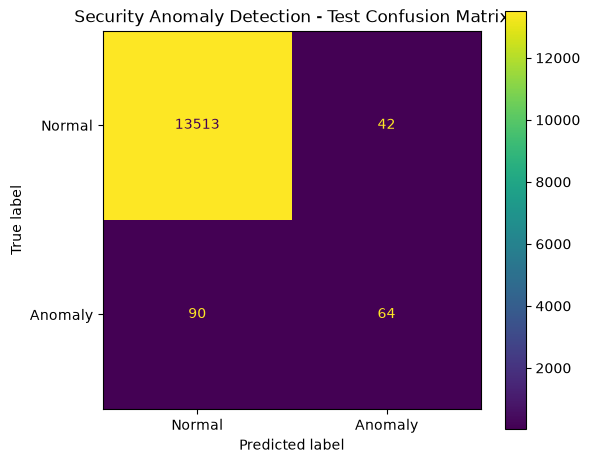

Confusion matrix saved.
Path: C:\Users\sarod\Desktop\Springboard\M3_Occupancy_and_Security_Intelligence\security_system\outputs\security_confusion_matrix.png


In [76]:
# Cell 76 — Save security confusion matrix

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(
    y_test,
    y_test_pred
)

fig, ax = plt.subplots(figsize=(6, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Anomaly"]
)

disp.plot(ax=ax)

ax.set_title("Security Anomaly Detection - Test Confusion Matrix")

plt.tight_layout()

confusion_matrix_path = (
    security_outputs_dir
    / "security_confusion_matrix.png"
)

plt.savefig(
    confusion_matrix_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Confusion matrix saved.")
print("Path:", confusion_matrix_path)

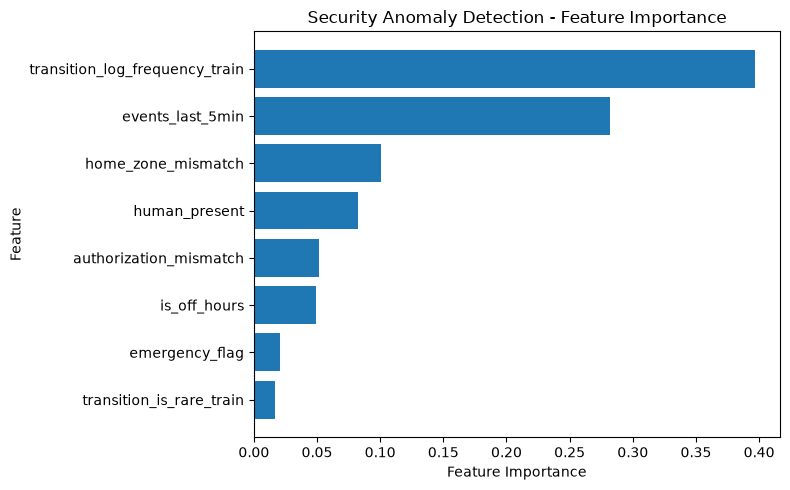

Feature importance plot saved.
Path: C:\Users\sarod\Desktop\Springboard\M3_Occupancy_and_Security_Intelligence\security_system\outputs\security_feature_importance.png


In [77]:
# Cell 77 — Save security feature importance plot

feature_importance_df = pd.DataFrame({
    "feature": final_feature_columns,
    "importance": security_model.feature_importances_
})

feature_importance_df = feature_importance_df.sort_values(
    "importance",
    ascending=True
)

plt.figure(figsize=(8, 5))

plt.barh(
    feature_importance_df["feature"],
    feature_importance_df["importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Security Anomaly Detection - Feature Importance")

plt.tight_layout()

feature_importance_path = (
    security_outputs_dir
    / "security_feature_importance.png"
)

plt.savefig(
    feature_importance_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Feature importance plot saved.")
print("Path:", feature_importance_path)

In [78]:
# Cell 78 — Save final security evaluation summary

import json

evaluation_summary = {
    "model": "RandomForestClassifier",
    "task": "Security anomaly detection",
    "threshold": 0.90,
    "features": final_feature_columns,
    "test_samples": int(len(y_test)),
    "test_anomalies": int(y_test.sum()),
    "test_normal": int((y_test == 0).sum()),
    "test_metrics": {
        "precision": 0.6038,
        "recall": 0.4156,
        "f1_score": 0.4923,
        "roc_auc": 0.9086,
        "pr_auc": 0.4562
    },
    "test_confusion_matrix": cm.tolist(),
    "model_parameters": {
        "n_estimators": 200,
        "max_depth": 12,
        "min_samples_leaf": 3,
        "class_weight": "balanced",
        "random_state": 42
    }
}

evaluation_path = (
    security_outputs_dir
    / "security_evaluation_summary.json"
)

with open(evaluation_path, "w") as file:
    json.dump(
        evaluation_summary,
        file,
        indent=2
    )

print("Security evaluation summary saved.")
print("Path:", evaluation_path)

print("\nTest metrics:")
for metric, value in evaluation_summary["test_metrics"].items():
    print(f"{metric}: {value}")

Security evaluation summary saved.
Path: C:\Users\sarod\Desktop\Springboard\M3_Occupancy_and_Security_Intelligence\security_system\outputs\security_evaluation_summary.json

Test metrics:
precision: 0.6038
recall: 0.4156
f1_score: 0.4923
roc_auc: 0.9086
pr_auc: 0.4562
